In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataclass = Processing(source_path=config.ORIG_FEATURES_FILE_PATH)
# Step 1: Read the data from the source path 
dataclass.read()

# Step 2: Preprocess the data
df = dataclass.preprocess()

#print(df.head())

# Step 3: Separate the features (X) and the target (y)
# The 'group_name' column is the target we want to predict, and the others are the features
X = df.drop(columns=['group_name'])  # Features (excluding the target)
y = df['group_name']  # Target

# Step 4: Split the data into training, validation, and test sets
# Split into 80% (train+val) and 20% (test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the 80% (train+val) into 70% (train) and 10% (validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42) # Final split: 0.7 train, 0.1 val, 0.2 test

# Step 5: Create the XGBoost model
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)

# Step 6: Train the model on the training set
model.fit(X_train, y_train)

# Step 7: Evaluate the model on the validation set
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')

# Step 8: After validation, test the model on the test set
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')


Accuracy on the validation set: 76.92%
Accuracy on the test set: 88.31%


97


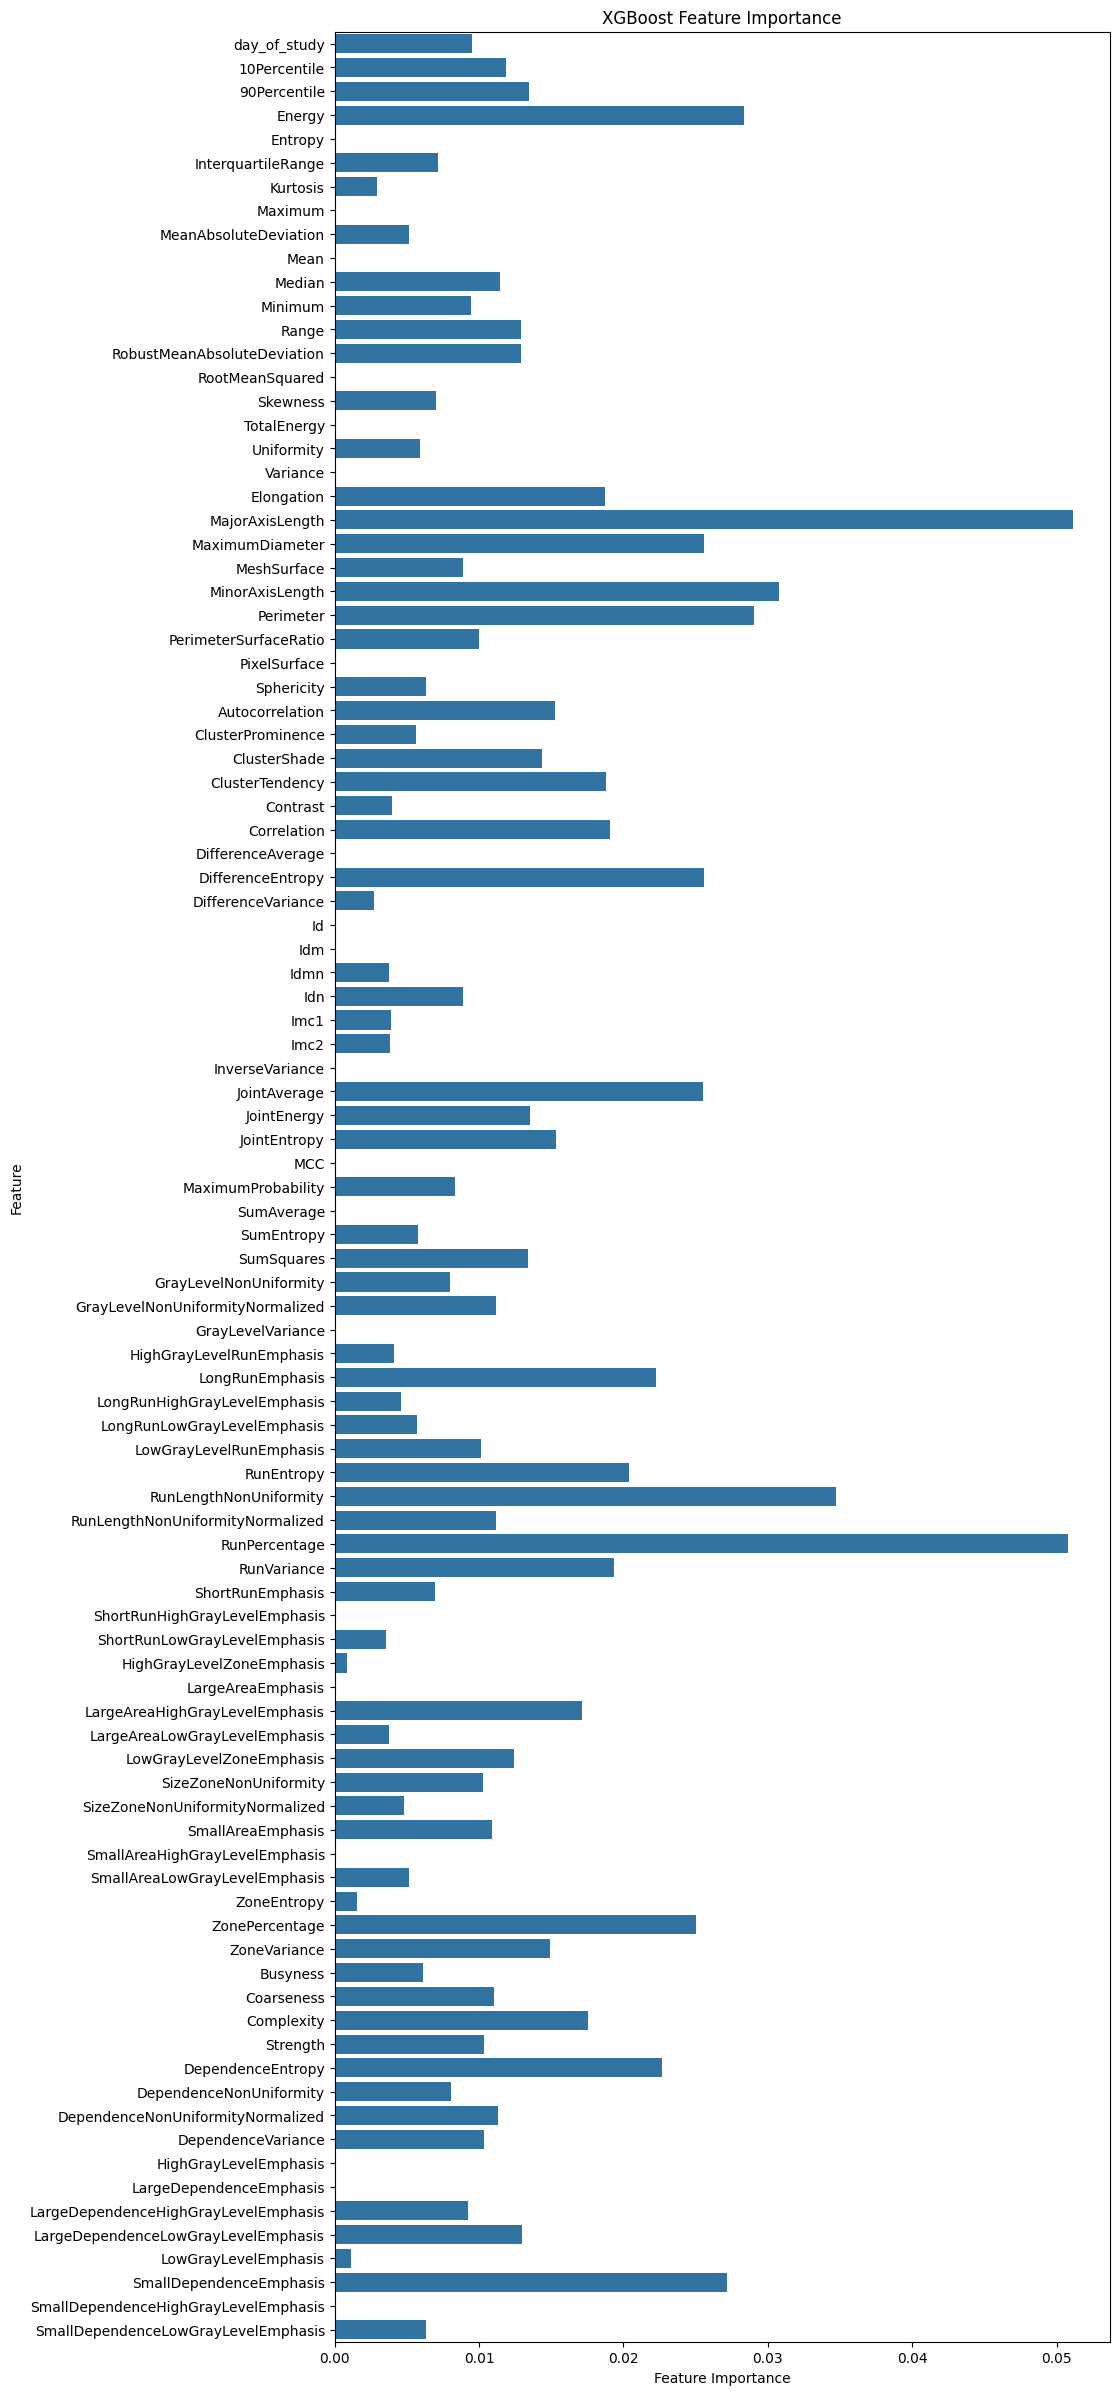

In [3]:
# Plot the feature importance
print(len(model.feature_importances_))

plt.figure(figsize=(10, 30))
sns.barplot(x=model.feature_importances_, y=X.columns)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()



Accuracy on the validation set (selected features): 79.49%
Accuracy on the test set (selected features): 84.42%
10


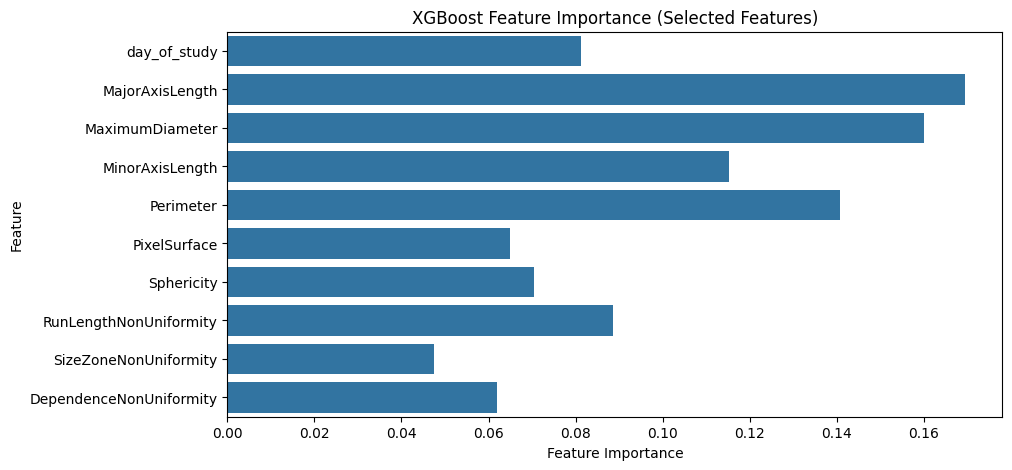

In [4]:
# Apply feature selection

# Select the top 10 features
selector = SelectKBest(chi2, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# Train a new XGBoost model on the selected features
model_selected = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model_selected.fit(X_train_selected, y_train)

# Evaluate the model on the validation set
y_val_pred = model_selected.predict(X_val_selected)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set (selected features): {val_accuracy * 100:.2f}%')

# Evaluate the model on the test set
y_test_pred = model_selected.predict(X_test_selected)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set (selected features): {test_accuracy * 100:.2f}%')

# Plot the feature importance
print(len(model_selected.feature_importances_))

plt.figure(figsize=(10, 5))
sns.barplot(x=model_selected.feature_importances_, y=X.columns[selector.get_support()])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance (Selected Features)')
plt.show()


In [5]:
# Train a SVM model
svm_model = svm.SVC()
svm_model.fit(X_train, y_train)
y_val_pred = svm_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')

y_test_pred = svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')

Accuracy on the validation set: 69.23%
Accuracy on the test set: 89.61%


In [6]:
# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_val_pred = rf_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')

y_test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')



Accuracy on the validation set: 76.92%
Accuracy on the test set: 89.61%
